## 1. Memahami Struktur Dataset & Demografi Annotator

Dataset Teks & Anotasi : 28,448 baris | 14 kolom
Dataset Demografi     : 29 annotator | 11 atribut


,Nama Kolom,Tipe Data,Contoh Nilai,Keterangan / Fungsi
0,text_id,object,1-1,ID unik untuk setiap sampel teks komentar
1,annotators_id,object,"['7', '15']",Daftar ID annotator yang menilai sampel (forma...
2,text,object,Wajah Jurnalis Dibalut Perban Saat ...,Konten teks komentar media sosial
3,initial_paragraph,object,“️Jurnalis Hana Mahamed kembali tam...,Konteks rujukan/paragraf berita induk (opsional)
4,topic,object,UNKNOWN,"Kelompok/isu yang dibahas (SARA, Disabilitas, ..."
5,is_noise_or_spam_text,object,"['0', '0']",Label deteksi teks spam/promosi/noise bot
6,related_to_election_2024,object,"['0', '0']",Label keterkaitan komentar dengan Pilpres/Pemi...
7,toxicity,object,"['0', '0']",Label utama toksisitas (komentar beracun/agresif)
8,polarized,object,"['0', '0']",Label polarisasi/perpecahan antarkelompok
9,profanity_obscenity,object,"['0', '0']",Label kata kotor/makian/vulgar


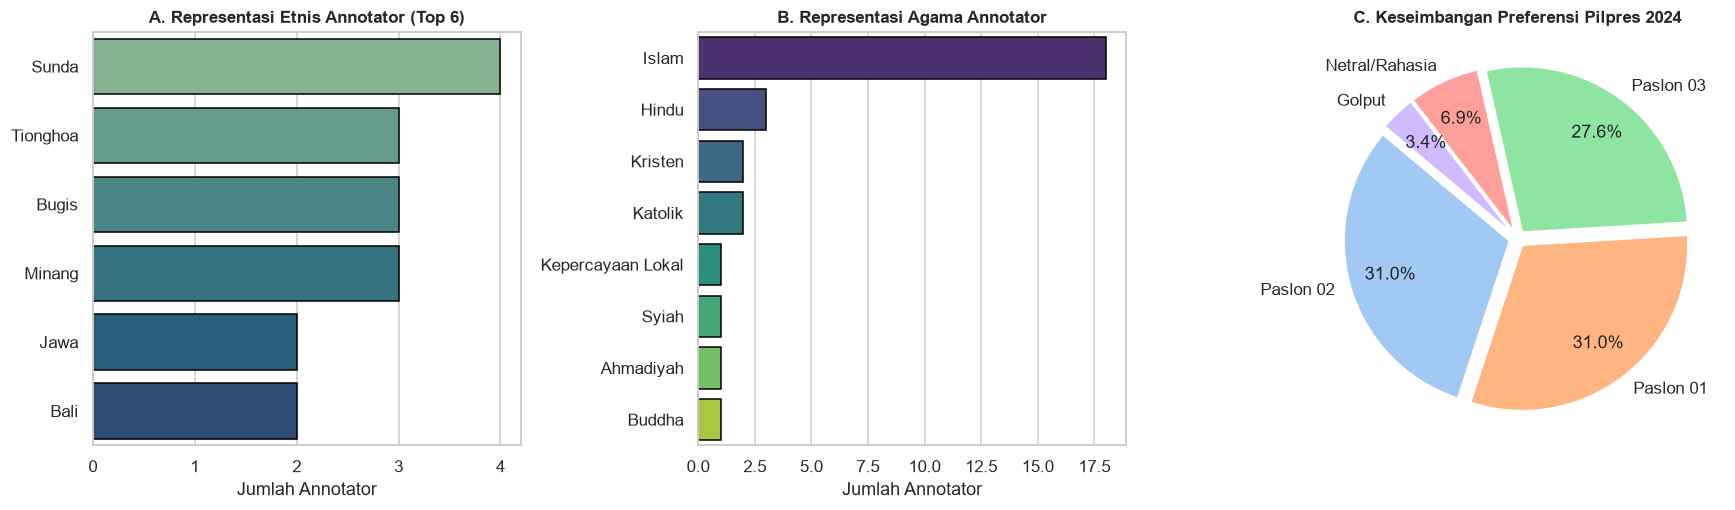

In [9]:
import os, sys, ast, re, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from IPython.display import display
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['figure.dpi'] = 110
nltk.download('stopwords', quiet=True)
if hasattr(sys.stdout, 'reconfigure'):
    try: sys.stdout.reconfigure(encoding='utf-8')
    except: pass

# 1. Helper Path Discovery Otomatis
def find_data_file(filename):
    candidates = [
        os.path.join('data', 'raw', filename),
        os.path.join('..', 'data', 'raw', filename),
        os.path.join('..', '..', 'data', 'raw', filename),
        filename,
        os.path.join('..', filename),
        os.path.join('..', '..', filename)
    ]
    for p in candidates:
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"File {filename} tidak ditemukan pada lokasi standar.")

path_annot = find_data_file('indotoxic2024_annotated.csv')
path_demo = find_data_file('indotoxic2024_annotator_demographics.csv')

df = pd.read_csv(path_annot)
df_demo = pd.read_csv(path_demo)

print("=" * 65)
print(f"Dataset Teks & Anotasi : {df.shape[0]:,} baris | {df.shape[1]} kolom")
print(f"Dataset Demografi     : {df_demo.shape[0]:,} annotator | {df_demo.shape[1]} atribut")
print("=" * 65)

# 2. Kamus Atribut dan Definisi Label
arti_label = {
    'text_id': 'ID unik untuk setiap sampel teks komentar',
    'annotators_id': 'Daftar ID annotator yang menilai sampel (format multi-annotator)',
    'text': 'Konten teks komentar media sosial',
    'initial_paragraph': 'Konteks rujukan/paragraf berita induk (opsional)',
    'topic': 'Kelompok/isu yang dibahas (SARA, Disabilitas, Politik, dll.)',
    'is_noise_or_spam_text': 'Label deteksi teks spam/promosi/noise bot',
    'related_to_election_2024': 'Label keterkaitan komentar dengan Pilpres/Pemilu 2024',
    'toxicity': 'Label utama toksisitas (komentar beracun/agresif)',
    'polarized': 'Label polarisasi/perpecahan antarkelompok',
    'profanity_obscenity': 'Label kata kotor/makian/vulgar',
    'threat_incitement_to_violence': 'Label ancaman/hasutan kekerasan',
    'insults': 'Label ujaran penghinaan/merendahkan martabat',
    'identity_attack': 'Label serangan kebencian berbasis identitas/SARA',
    'sexually_explicit': 'Label konten seksual eksplisit'
}

df_struktur = pd.DataFrame({
    'Nama Kolom': df.columns,
    'Tipe Data': df.dtypes.values,
    'Contoh Nilai': [str(df[c].iloc[0])[:35] + '...' if len(str(df[c].iloc[0])) > 35 else str(df[c].iloc[0]) for c in df.columns],
    'Keterangan / Fungsi': [arti_label.get(c, '-') for c in df.columns]
})
display(df_struktur)

# 3. Visualisasi Profil Keberagaman 29 Annotator (Layout Bersih Tanpa Tabrakan)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

# Panel A: Etnisitas Annotator
etnis_counts = df_demo['ethnicity'].value_counts().head(6)
sns.barplot(x=etnis_counts.values, y=etnis_counts.index, palette='crest', ax=axes[0], edgecolor='black')
axes[0].set_title('A. Representasi Etnis Annotator (Top 6)', fontweight='bold', fontsize=11)
axes[0].set_xlabel('Jumlah Annotator')
axes[0].set_ylabel('')

# Panel B: Agama & Kepercayaan Annotator
agama_counts = df_demo['religion'].value_counts()
sns.barplot(x=agama_counts.values, y=agama_counts.index, palette='viridis', ax=axes[1], edgecolor='black')
axes[1].set_title('B. Representasi Agama Annotator', fontweight='bold', fontsize=11)
axes[1].set_xlabel('Jumlah Annotator')
axes[1].set_ylabel('')

# Panel C: Orientasi Dukungan Politik (Pilpres 2024)
paslon_counts = df_demo['president vote leaning'].astype(str).str.strip().value_counts()
paslon_labels = {'1': 'Paslon 01', '2': 'Paslon 02', '3': 'Paslon 03', 'Golput': 'Golput', '-': 'Netral/Rahasia'}
paslon_names = [paslon_labels.get(k, k) for k in paslon_counts.index]
axes[2].pie(paslon_counts.values, labels=paslon_names, autopct='%1.1f%%',
            startangle=140, colors=sns.color_palette('pastel'), explode=[0.05]*len(paslon_counts),
            pctdistance=0.75)
axes[2].set_title('C. Keseimbangan Preferensi Pilpres 2024', fontweight='bold', fontsize=11)

plt.subplots_adjust(wspace=0.35)
plt.tight_layout()
plt.show()

## 2. Memeriksa Kualitas Data & Audit Teks Spam/Noise

Data kosong kolom 'text'              : 1 baris
Data kosong kolom 'initial_paragraph' : 26,779 baris (wajar, konteks opsional)
-> Baris teks kosong berhasil dibersihkan.
Duplikasi baris penuh               : 0
Duplikasi konten teks               : 2,274 teks

Ringkasan Audit Teks Spam:


,Status Konten,Jumlah Sampel,Persentase (%),Rata-rata Kata,Rata-rata Karakter
0,Teks Asli Organik (0),26165,91.98,44.5,315.4
1,Teks Spam/Noise Bot (1),2282,8.02,36.6,247.9


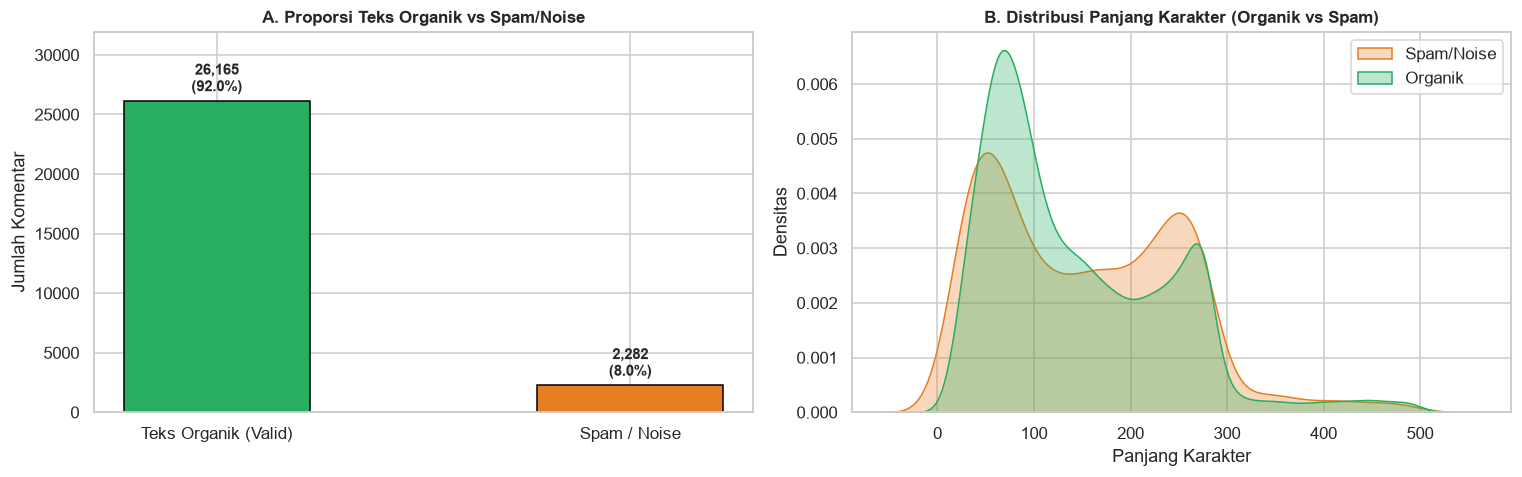

In [10]:
# 1. Pengecekan Missing Values
missing_text = df['text'].isnull().sum()
missing_init = df['initial_paragraph'].isnull().sum()
print(f"Data kosong kolom 'text'              : {missing_text:,} baris")
print(f"Data kosong kolom 'initial_paragraph' : {missing_init:,} baris (wajar, konteks opsional)")

# Drop data jika teks kosong
if missing_text > 0:
    df = df.dropna(subset=['text']).reset_index(drop=True)
    print("-> Baris teks kosong berhasil dibersihkan.")

# 2. Pengecekan Duplikasi
dup_full = df.duplicated().sum()
dup_text = df['text'].duplicated().sum()
print(f"Duplikasi baris penuh               : {dup_full:,}")
print(f"Duplikasi konten teks               : {dup_text:,} teks")

# 3. Helper Parse Nilai List String ke Rata-rata
def parse_vote_mean(val):
    if not isinstance(val, str): return 0.0
    try:
        arr = [float(v) for v in ast.literal_eval(val)]
        return np.mean(arr) if len(arr) > 0 else 0.0
    except:
        return 0.0

df['spam_score'] = df['is_noise_or_spam_text'].apply(parse_vote_mean)
df['is_spam'] = (df['spam_score'] >= 0.5).astype(int)

# Hitung jumlah kata dan karakter
df['char_len'] = df['text'].astype(str).str.len()
df['word_count'] = df['text'].astype(str).str.split().str.len()

spam_summary = pd.DataFrame({
    'Status Konten': ['Teks Asli Organik (0)', 'Teks Spam/Noise Bot (1)'],
    'Jumlah Sampel': df['is_spam'].value_counts().sort_index().values,
    'Persentase (%)': (df['is_spam'].value_counts(normalize=True).sort_index() * 100).round(2).values,
    'Rata-rata Kata': df.groupby('is_spam')['word_count'].mean().round(1).values,
    'Rata-rata Karakter': df.groupby('is_spam')['char_len'].mean().round(1).values
})
print("\nRingkasan Audit Teks Spam:")
display(spam_summary)

# Visualisasi Audit Kualitas Data: Spam vs Non-Spam
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Panel A: Proporsi Teks Spam
spam_counts = df['is_spam'].value_counts()
axes[0].bar(['Teks Organik (Valid)', 'Spam / Noise'], spam_counts.values,
            color=['#27AE60', '#E67E22'], edgecolor='black', width=0.45)
max_spam_val = max(spam_counts.values)
axes[0].set_ylim(0, max_spam_val * 1.22)
for p in axes[0].patches:
    y = p.get_height()
    axes[0].annotate(f"{y:,}\n({y/len(df)*100:.1f}%)", (p.get_x() + p.get_width()/2, y + max_spam_val * 0.03),
                     ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('A. Proporsi Teks Organik vs Spam/Noise', fontweight='bold', fontsize=11)
axes[0].set_ylabel('Jumlah Komentar')

# Panel B: Distribusi Panjang Karakter (KDE)
sns.kdeplot(data=df[df['char_len'] <= 500], x='char_len', hue='is_spam', common_norm=False,
            palette=['#27AE60', '#E67E22'], fill=True, alpha=0.3, ax=axes[1])
axes[1].set_title('B. Distribusi Panjang Karakter (Organik vs Spam)', fontweight='bold', fontsize=11)
axes[1].set_xlabel('Panjang Karakter')
axes[1].set_ylabel('Densitas')
axes[1].legend(['Spam/Noise', 'Organik'], loc='upper right')

plt.tight_layout()
plt.show()

## 3. Subjektivitas Anotasi & Cross-Demographic Perception Bias

Distribusi Konsensus Annotator pada Label Toxicity:


,Kategori Konsensus,Jumlah Sampel,Persentase (%)
0,Sepakat Bersih (0-0),23174,81.46
1,Berselisih Pendapat (Borderline),3858,13.56
2,Sepakat Toksik (1-1),1415,4.97



Disparitas Sensitivitas Penilaian Annotator pada Topik 'Disabilitas':


,Jumlah Penilaian,Sensitivitas Toksik (%)
ann_religion,,
Kepercayaan Lokal,480,24.4
Hindu,1474,23.5
Islam,7017,19.0
Syiah,477,15.5
Buddha,467,9.2
Katolik,1347,8.2
Kristen,1258,5.0


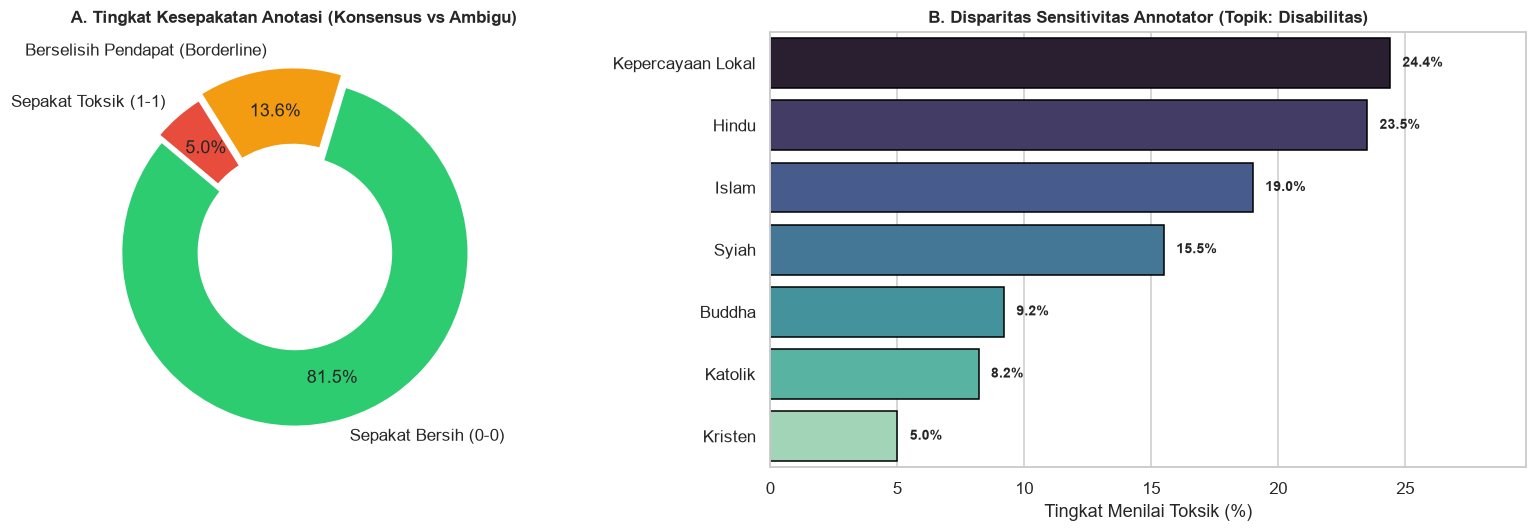

In [11]:
# 1. Ekstraksi Tingkat Kesepakatan Anotasi Toxicity
def get_agreement_category(val):
    if not isinstance(val, str): return 'Invalid'
    try:
        arr = [int(v) for v in ast.literal_eval(val)]
        if len(arr) == 0: return 'Invalid'
        s = sum(arr)
        if s == 0: return 'Sepakat Bersih (0-0)'
        elif s == len(arr): return 'Sepakat Toksik (1-1)'
        else: return 'Berselisih Pendapat (Borderline)'
    except:
        return 'Invalid'

df['consensus_cat'] = df['toxicity'].apply(get_agreement_category)
agree_counts = df['consensus_cat'].value_counts()

agree_table = pd.DataFrame({
    'Kategori Konsensus': agree_counts.index,
    'Jumlah Sampel': agree_counts.values,
    'Persentase (%)': (agree_counts.values / len(df) * 100).round(2)
})
print("Distribusi Konsensus Annotator pada Label Toxicity:")
display(agree_table)

# 2. Analisis Cross-Demographic Perception Bias
demo_dict = df_demo.set_index('annotator_id').to_dict('index')

topic_pairs = []
for _, row in df.iterrows():
    top = str(row['topic']).strip()
    try:
        aids = [int(x) for x in ast.literal_eval(row['annotators_id'])]
        t_arr = [int(x) for x in ast.literal_eval(row['toxicity'])]
        for aid, tval in zip(aids, t_arr):
            if aid in demo_dict:
                topic_pairs.append({
                    'annotator_id': aid,
                    'ann_religion': demo_dict[aid]['religion'],
                    'topic': top,
                    'is_toxic': tval
                })
    except:
        pass

df_pairs = pd.DataFrame(topic_pairs)

# Disparitas Sensitivitas pada Topik Disabilitas
bias_dis = df_pairs[df_pairs['topic'].str.contains('Disabilitas', na=False)].groupby('ann_religion')['is_toxic'].agg(['count', 'mean'])
bias_dis = bias_dis[bias_dis['count'] >= 50].sort_values('mean', ascending=False)
bias_dis['mean'] = (bias_dis['mean'] * 100).round(1)
bias_dis.columns = ['Jumlah Penilaian', 'Sensitivitas Toksik (%)']

print("\nDisparitas Sensitivitas Penilaian Annotator pada Topik 'Disabilitas':")
display(bias_dis)

# 3. Visualisasi Konsensus & Disparitas Latar Belakang Annotator
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel A: Donut Chart Konsensus
colors_agree = ['#2ECC71', '#F39C12', '#E74C3C']
axes[0].pie(agree_counts.values, labels=agree_counts.index, autopct='%1.1f%%',
            startangle=140, colors=colors_agree, explode=[0.02, 0.05, 0.02],
            wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2),
            pctdistance=0.75)
axes[0].set_title('A. Tingkat Kesepakatan Anotasi (Konsensus vs Ambigu)', fontweight='bold', fontsize=11)

# Panel B: Disparitas Sensitivitas per Agama Annotator pada Isu Disabilitas
max_bias_val = max(bias_dis['Sensitivitas Toksik (%)'])
sns.barplot(x=bias_dis['Sensitivitas Toksik (%)'].values, y=bias_dis.index, palette='mako', ax=axes[1], edgecolor='black')
axes[1].set_title('B. Disparitas Sensitivitas Annotator (Topik: Disabilitas)', fontweight='bold', fontsize=11)
axes[1].set_xlabel('Tingkat Menilai Toksik (%)')
axes[1].set_ylabel('')
axes[1].set_xlim(0, max_bias_val * 1.22)
for p in axes[1].patches:
    w = p.get_width()
    axes[1].annotate(f"{w:.1f}%", (w + max_bias_val * 0.02, p.get_y() + p.get_height()/2),
                     va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Dinamika Multi-Label, Covert Toxicity & Kombinasi Serangan

Total Komentar Toksik                        : 3,995
Toksik Terang-terangan (Overt: Kata Kasar)  : 664 (16.6%)
Toksik Terselubung (Covert: Tanpa Kata Kasar): 3,331 (83.4%)

Top 6 Kombinasi Pelanggaran Multi-Label Terbanyak:


,Jumlah Teks,Persentase (%)
combo,,
polarized + insults,631,15.8
polarized + identity attack,575,14.4
insults,463,11.6
polarized + insults + identity attack,355,8.9
polarized + threat incitement to violence,352,8.8
identity attack,318,8.0


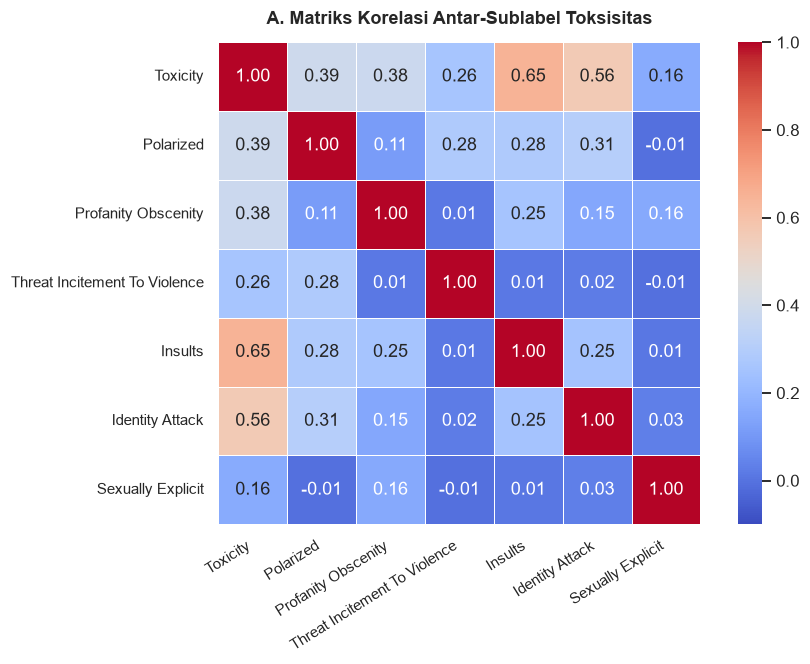

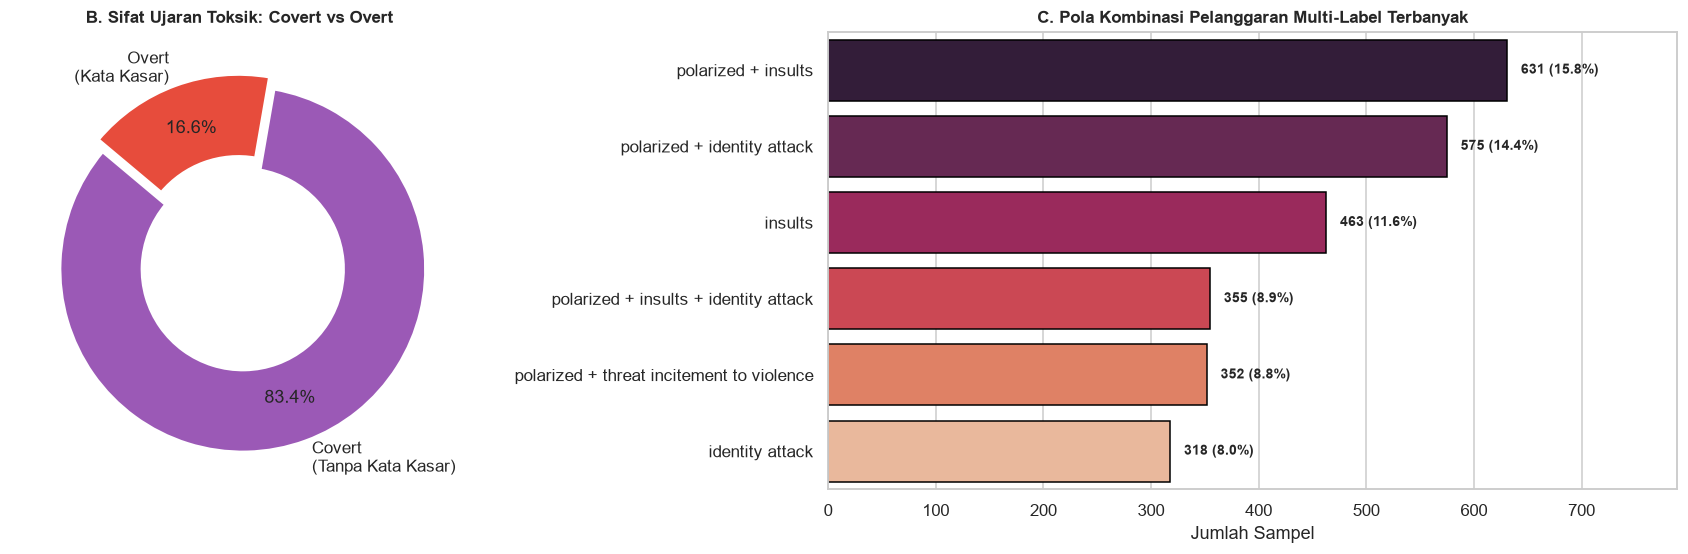

In [12]:
# 1. Terapkan Majority Voting Biner (Threshold >= 0.5)
label_cols = ['toxicity', 'polarized', 'profanity_obscenity', 'threat_incitement_to_violence',
              'insults', 'identity_attack', 'sexually_explicit']

for col in label_cols:
    df[col] = df[col].apply(lambda v: 1 if parse_vote_mean(v) >= 0.5 else 0)

# 2. Analisis Covert vs Overt Toxicity
total_tox = (df['toxicity'] == 1).sum()
covert_tox = ((df['toxicity'] == 1) & (df['profanity_obscenity'] == 0)).sum()
overt_tox = ((df['toxicity'] == 1) & (df['profanity_obscenity'] == 1)).sum()

print("=" * 70)
print(f"Total Komentar Toksik                        : {total_tox:,}")
print(f"Toksik Terang-terangan (Overt: Kata Kasar)  : {overt_tox:,} ({overt_tox/total_tox*100:.1f}%)")
print(f"Toksik Terselubung (Covert: Tanpa Kata Kasar): {covert_tox:,} ({covert_tox/total_tox*100:.1f}%)")
print("=" * 70)

# 3. Label Cardinality & Top Kombinasi Sub-label
sub_cols = ['polarized', 'profanity_obscenity', 'threat_incitement_to_violence', 'insults', 'identity_attack', 'sexually_explicit']
df['active_sublabels'] = df[sub_cols].sum(axis=1)

def get_combo(row):
    active = [col.replace('_', ' ') for col in sub_cols if row[col] == 1]
    return ' + '.join(active) if active else 'Hanya Toksisitas Umum (Tanpa Sublabel)'

df_tox = df[df['toxicity'] == 1].copy()
df_tox['combo'] = df_tox.apply(get_combo, axis=1)
top_combos = df_tox['combo'].value_counts().head(6)

print("\nTop 6 Kombinasi Pelanggaran Multi-Label Terbanyak:")
display(pd.DataFrame({'Jumlah Teks': top_combos.values, 'Persentase (%)': (top_combos.values/len(df_tox)*100).round(1)}, index=top_combos.index))

# 4. Visualisasi A: Matriks Korelasi 7 Sublabel (Plot Mandiri yang Luas & Rapi)
fig, ax = plt.subplots(figsize=(8.5, 6.2))
clean_sublabels = [c.replace('_', ' ').title() for c in label_cols]
sns.heatmap(df[label_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', cbar=True,
            vmin=-0.1, vmax=1.0, square=True, linewidths=0.5,
            xticklabels=clean_sublabels, yticklabels=clean_sublabels, ax=ax)
ax.set_title('A. Matriks Korelasi Antar-Sublabel Toksisitas', fontweight='bold', fontsize=12, pad=12)
plt.xticks(rotation=32, ha='right', fontsize=9.5)
plt.yticks(rotation=0, fontsize=9.5)
plt.tight_layout()
plt.show()

# 5. Visualisasi B & C: Sifat Ujaran Toksik (Donut) & Top Kombinasi Pelanggaran (Bebas Tabrakan)
fig, axes = plt.subplots(1, 2, figsize=(16, 5.2), gridspec_kw={'width_ratios': [1, 1.5]})

# Donut Chart Covert vs Overt
axes[0].pie([covert_tox, overt_tox], labels=['Covert\n(Tanpa Kata Kasar)', 'Overt\n(Kata Kasar)'],
            autopct='%1.1f%%', startangle=140, colors=['#9B59B6', '#E74C3C'], explode=[0.05, 0.02],
            wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2), pctdistance=0.75)
axes[0].set_title('B. Sifat Ujaran Toksik: Covert vs Overt', fontweight='bold', fontsize=11)

# Top Kombinasi Sub-label (Bar Horizontal dengan Spasi Sumbu Y Luas)
max_combo_val = max(top_combos.values)
sns.barplot(x=top_combos.values, y=top_combos.index, palette='rocket', ax=axes[1], edgecolor='black')
axes[1].set_title('C. Pola Kombinasi Pelanggaran Multi-Label Terbanyak', fontweight='bold', fontsize=11)
axes[1].set_xlabel('Jumlah Sampel')
axes[1].set_ylabel('')
axes[1].set_xlim(0, max_combo_val * 1.25)
for p in axes[1].patches:
    w = p.get_width()
    axes[1].annotate(f"{int(w):,} ({w/len(df_tox)*100:.1f}%)",
                     (w + max_combo_val * 0.02, p.get_y() + p.get_height()/2),
                     va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Kerentanan Berdasarkan Topik SARA & Profil Tokoh Politik

Tingkat Kerentanan Tiap Topik Terhadap Berbagai Bentuk Ujaran:


,Topik / Sasaran,Total Komentar,Toxicity (%),Identity Attack (%),Insults (%),Polarized (%)
6,Syiah,709,37.5,20.6,18.6,38.2
5,LGBTQ+,906,34.8,20.9,7.8,9.4
0,Jewish,8888,17.8,9.5,7.7,35.6
1,Disabilitas,6922,12.0,1.6,8.1,9.7
3,Kristen,1581,11.3,4.9,5.5,16.8
4,Rohingya,1490,7.3,3.5,4.0,50.1
2,Tionghoa,5555,7.2,4.2,3.2,13.6



Profil Ujaran Saat Nama Tokoh Politik Disebut:


,Tokoh Politik,Total Mentions,Toxicity (%),Polarized (%)
1,Prabowo,563,22.6,43.9
6,Jokowi,610,22.1,42.6
3,Gibran,583,21.4,41.0
0,Anies,569,19.5,43.6
4,Mahfud,458,14.2,42.8
2,Ganjar,1153,13.5,39.6
5,Muhaimin,146,8.2,27.4


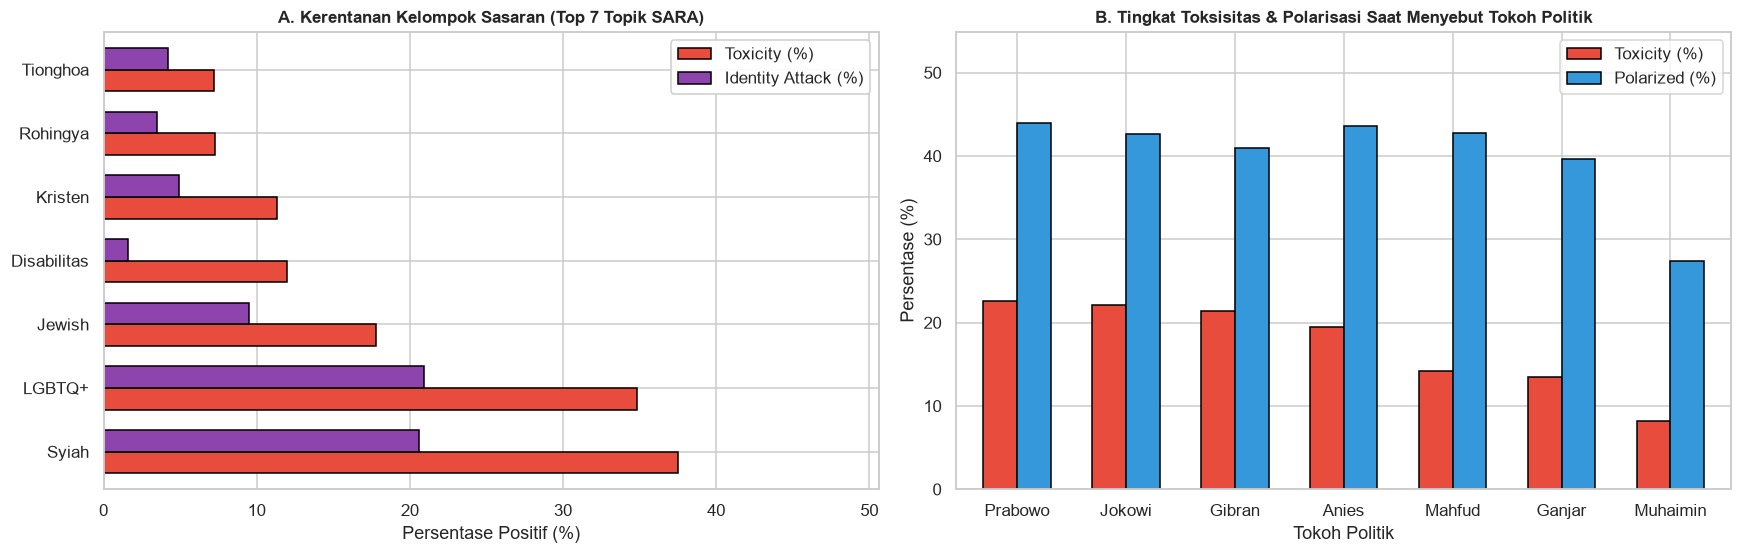

In [13]:
# 1. Normalisasi dan Ekstraksi Topik
df['top_topic'] = df['topic'].fillna('UNKNOWN').astype(str).apply(lambda x: [t.strip() for t in x.split(',')][0])
top_topics = df[~df['top_topic'].isin(['UNKNOWN', 'nan'])]['top_topic'].value_counts().head(7).index.tolist()

topic_analysis = []
for t in top_topics:
    sub = df[df['top_topic'] == t]
    topic_analysis.append({
        'Topik / Sasaran': t,
        'Total Komentar': len(sub),
        'Toxicity (%)': (sub['toxicity'].mean() * 100).round(1),
        'Identity Attack (%)': (sub['identity_attack'].mean() * 100).round(1),
        'Insults (%)': (sub['insults'].mean() * 100).round(1),
        'Polarized (%)': (sub['polarized'].mean() * 100).round(1)
    })

df_topic_res = pd.DataFrame(topic_analysis).sort_values('Toxicity (%)', ascending=False)
print("Tingkat Kerentanan Tiap Topik Terhadap Berbagai Bentuk Ujaran:")
display(df_topic_res)

# 2. Analisis Mention Nama Kandidat / Tokoh Politik
tokoh_list = ['anies', 'prabowo', 'ganjar', 'gibran', 'mahfud', 'muhaimin', 'jokowi']
tokoh_stats = []
for tokoh in tokoh_list:
    sub = df[df['text'].astype(str).str.lower().str.contains(tokoh)]
    if len(sub) > 0:
        tokoh_stats.append({
            'Tokoh Politik': tokoh.capitalize(),
            'Total Mentions': len(sub),
            'Toxicity (%)': round(sub['toxicity'].mean() * 100, 1),
            'Polarized (%)': round(sub['polarized'].mean() * 100, 1)
        })

df_tokoh = pd.DataFrame(tokoh_stats).sort_values('Toxicity (%)', ascending=False)
print("\nProfil Ujaran Saat Nama Tokoh Politik Disebut:")
display(df_tokoh)

# 3. Visualisasi 2-Panel: Kerentanan Topik & Profil Tokoh Politik (Bebas Tabrakan Legend & Batas Y)
fig, axes = plt.subplots(1, 2, figsize=(16, 5.2))

# Panel A: Tingkat Toksisitas & Identity Attack per Topik
max_topic_val = max(df_topic_res['Toxicity (%)'])
plot_topic = df_topic_res.set_index('Topik / Sasaran')[['Toxicity (%)', 'Identity Attack (%)']]
plot_topic.plot(kind='barh', ax=axes[0], color=['#E74C3C', '#8E44AD'], edgecolor='black', width=0.68)
axes[0].set_title('A. Kerentanan Kelompok Sasaran (Top 7 Topik SARA)', fontweight='bold', fontsize=11)
axes[0].set_xlabel('Persentase Positif (%)')
axes[0].set_ylabel('')
axes[0].set_xlim(0, max_topic_val * 1.35)
axes[0].legend(['Toxicity (%)', 'Identity Attack (%)'], loc='upper right', framealpha=0.95)

# Panel B: Toksisitas & Polarisasi per Tokoh Politik
df_tokoh_plot = df_tokoh.set_index('Tokoh Politik')[['Toxicity (%)', 'Polarized (%)']]
max_tokoh_val = max(df_tokoh['Toxicity (%)'].max(), df_tokoh['Polarized (%)'].max())
df_tokoh_plot.plot(kind='bar', ax=axes[1], color=['#E74C3C', '#3498DB'], edgecolor='black', width=0.62)
axes[1].set_title('B. Tingkat Toksisitas & Polarisasi Saat Menyebut Tokoh Politik', fontweight='bold', fontsize=11)
axes[1].set_xlabel('Tokoh Politik')
axes[1].set_ylabel('Persentase (%)')
axes[1].set_ylim(0, max_tokoh_val * 1.25)
axes[1].legend(['Toxicity (%)', 'Polarized (%)'], loc='upper right')
plt.setp(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

## 6. Stylometri Teks: Deteksi Huruf Kapital (SHOUTING), Tanda Baca & Length Buckets

Distribusi Toksisitas Berdasarkan Rentang Panjang Komentar:


,Jumlah Sampel,Toxicity (%)
length_bucket,,
1-5 kata (Ultra Pendek),1126,11.7
6-15 kata (Pendek),9600,12.2
16-35 kata (Sedang),9403,16.0
36-70 kata (Panjang),4183,17.5
>70 kata (Ultra Panjang),3985,11.4



Pengaruh Gaya Penulisan terhadap Lonjakan Toksisitas:
- Huruf Kapital Normal : 13.8% -> SHOUTING / ALL-CAPS : 19.3% (+5.5%)
- Tanda Seru Tunggal   : 13.7% -> Tanda Seru Ganda (!!+) : 20.1% (+6.4%)
- Tanda Tanya Tunggal  : 13.8% -> Tanda Tanya Ganda (??+): 21.3% (+7.5%)


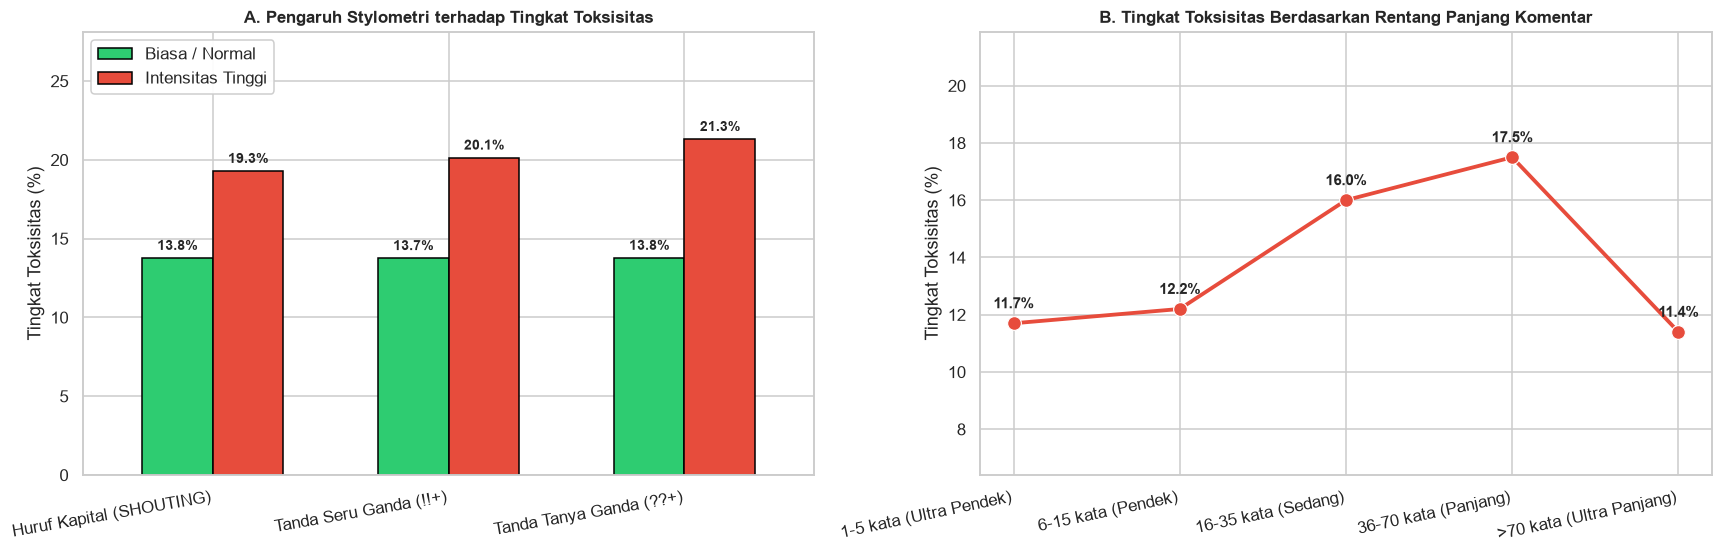

In [14]:
# 1. Ekstraksi Fitur Stylometri Teks
def extract_stylometry(text):
    text = str(text)
    alpha_chars = [c for c in text if c.isalpha()]
    caps_ratio = sum(1 for c in alpha_chars if c.isupper()) / max(len(alpha_chars), 1)
    is_shouting = 1 if (caps_ratio >= 0.5 and len(alpha_chars) >= 8) else 0
    excl_count = text.count('!')
    qmark_count = text.count('?')
    has_multi_excl = 1 if excl_count >= 2 else 0
    has_multi_qmark = 1 if qmark_count >= 2 else 0
    return pd.Series([caps_ratio, is_shouting, has_multi_excl, has_multi_qmark])

df[['caps_ratio', 'is_shouting', 'has_multi_excl', 'has_multi_qmark']] = df['text'].apply(extract_stylometry)

# 2. Length Buckets
df['length_bucket'] = pd.cut(df['word_count'], bins=[0, 5, 15, 35, 70, 500],
                             labels=['1-5 kata (Ultra Pendek)', '6-15 kata (Pendek)', '16-35 kata (Sedang)', '36-70 kata (Panjang)', '>70 kata (Ultra Panjang)'])

bucket_res = df.groupby('length_bucket', observed=False)['toxicity'].agg(['count', 'mean'])
bucket_res['mean'] = (bucket_res['mean'] * 100).round(1)
bucket_res.columns = ['Jumlah Sampel', 'Toxicity (%)']
print("Distribusi Toksisitas Berdasarkan Rentang Panjang Komentar:")
display(bucket_res)

# 3. Komparasi Stylometri
shout_stat = df.groupby('is_shouting')['toxicity'].mean() * 100
excl_stat = df.groupby('has_multi_excl')['toxicity'].mean() * 100
qmark_stat = df.groupby('has_multi_qmark')['toxicity'].mean() * 100

print(f"\nPengaruh Gaya Penulisan terhadap Lonjakan Toksisitas:")
print(f"- Huruf Kapital Normal : {shout_stat[0]:.1f}% -> SHOUTING / ALL-CAPS : {shout_stat[1]:.1f}% (+{shout_stat[1]-shout_stat[0]:.1f}%)")
print(f"- Tanda Seru Tunggal   : {excl_stat[0]:.1f}% -> Tanda Seru Ganda (!!+) : {excl_stat[1]:.1f}% (+{excl_stat[1]-excl_stat[0]:.1f}%)")
print(f"- Tanda Tanya Tunggal  : {qmark_stat[0]:.1f}% -> Tanda Tanya Ganda (??+): {qmark_stat[1]:.1f}% (+{qmark_stat[1]-qmark_stat[0]:.1f}%)")

# 4. Visualisasi 2-Panel: Pengaruh Stylometri & Kurva Panjang Kata (Bebas Potongan Ylim)
fig, axes = plt.subplots(1, 2, figsize=(16, 5.2))

# Panel A: Bar Chart Pengaruh Gaya Stylometri
style_df = pd.DataFrame({
    'Biasa / Normal': [shout_stat[0], excl_stat[0], qmark_stat[0]],
    'Intensitas Tinggi': [shout_stat[1], excl_stat[1], qmark_stat[1]]
}, index=['Huruf Kapital (SHOUTING)', 'Tanda Seru Ganda (!!+)', 'Tanda Tanya Ganda (??+)'])

max_style_val = max(shout_stat.max(), excl_stat.max(), qmark_stat.max(), style_df.values.max())
style_df.plot(kind='bar', color=['#2ECC71', '#E74C3C'], edgecolor='black', ax=axes[0], width=0.6)
axes[0].set_title('A. Pengaruh Stylometri terhadap Tingkat Toksisitas', fontweight='bold', fontsize=11)
axes[0].set_ylabel('Tingkat Toksisitas (%)')
axes[0].set_ylim(0, max_style_val * 1.32)
axes[0].legend(['Biasa / Normal', 'Intensitas Tinggi'], loc='upper left', framealpha=0.95)
plt.setp(axes[0].get_xticklabels(), rotation=10, ha='right')
for p in axes[0].patches:
    h = p.get_height()
    if h > 0:
        axes[0].annotate(f"{h:.1f}%", (p.get_x() + p.get_width()/2, h + max_style_val * 0.025),
                         ha='center', fontsize=9, fontweight='bold')

# Panel B: Kurva Tingkat Toksisitas per Length Bucket
max_bucket_val = bucket_res['Toxicity (%)'].max()
min_bucket_val = bucket_res['Toxicity (%)'].min()
sns.lineplot(x=range(len(bucket_res)), y=bucket_res['Toxicity (%)'].values,
             marker='o', markersize=9, color='#E74C3C', lw=2.5, ax=axes[1])
axes[1].set_xticks(range(len(bucket_res)))
axes[1].set_xticklabels(bucket_res.index, rotation=12, ha='right')
axes[1].set_title('B. Tingkat Toksisitas Berdasarkan Rentang Panjang Komentar', fontweight='bold', fontsize=11)
axes[1].set_ylabel('Tingkat Toksisitas (%)')
axes[1].set_ylim(max(0, min_bucket_val - 5), max_bucket_val * 1.25)
for i, v in enumerate(bucket_res['Toxicity (%)'].values):
    axes[1].annotate(f"{v:.1f}%", (i, v + max_bucket_val * 0.03), ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

## 7. Analisis Karakter Emoji sebagai Emotional Amplifier

Baseline Toksisitas Korpus: 14.0%
Pengaruh Kemunculan Karakter Emoji terhadap Lonjakan Toksisitas:


,Emoji,Deskripsi / Makna,Total Teks,Toxicity (%),Polarized (%),Multiplier vs Baseline
0,🤦,Facepalm / Kecewa Berat,32,53.1,46.9,3.78
1,👎,Thumbs Down / Penolakan,18,50.0,44.4,3.56
2,😡,Angry / Amarah,50,48.0,42.0,3.42
3,🤮,Vomit / Rasa Jijik,17,47.1,35.3,3.35
4,🤬,Swearing / Umpatan,15,46.7,40.0,3.32
5,🤡,Clown / Badut Politik,13,38.5,38.5,2.74
6,😂,Tears of Joy / Ejekan Sinetron,238,26.5,29.0,1.88
7,🤣,ROFL / Sarkasme Politik,393,26.5,28.2,1.88


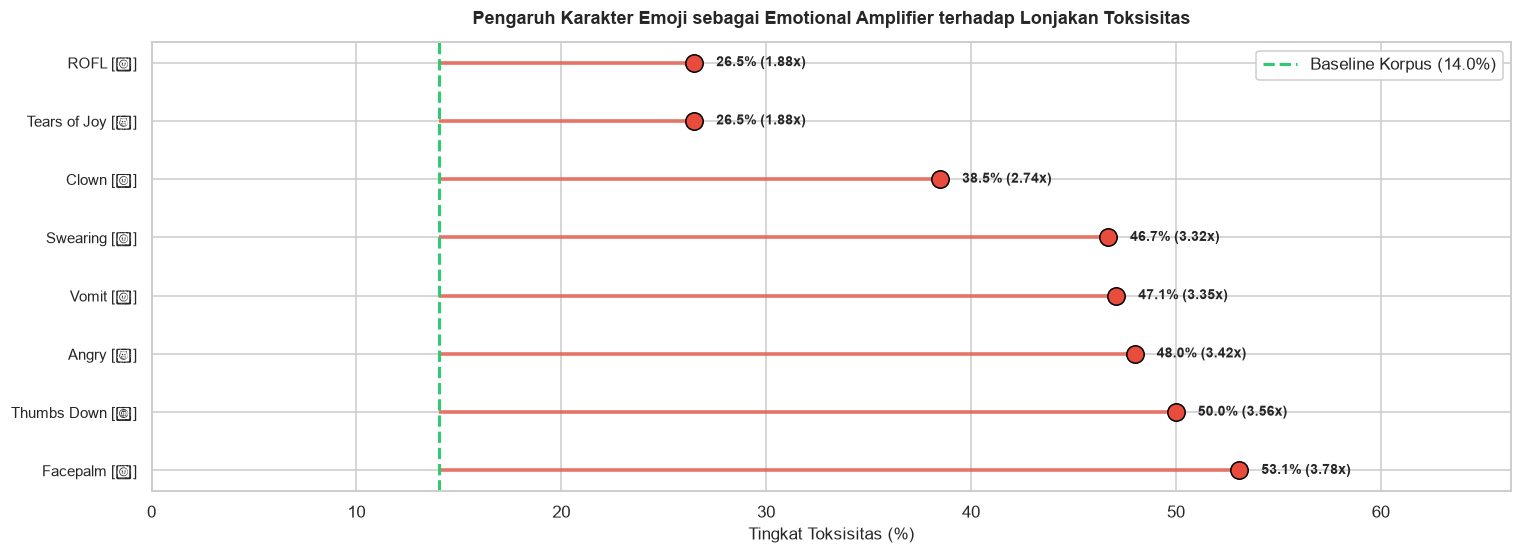

In [15]:
# 1. Audit Frekuensi dan Toksisitas per Emoji
emojis_to_test = [
    ('🤦', 'Facepalm / Kecewa Berat'),
    ('👎', 'Thumbs Down / Penolakan'),
    ('😡', 'Angry / Amarah'),
    ('🤮', 'Vomit / Rasa Jijik'),
    ('🤬', 'Swearing / Umpatan'),
    ('🤡', 'Clown / Badut Politik'),
    ('😂', 'Tears of Joy / Ejekan Sinetron'),
    ('🤣', 'ROFL / Sarkasme Politik')
]

baseline_tox = df['toxicity'].mean() * 100
emoji_stats = []

for emo, makna in emojis_to_test:
    sub = df[df['text'].astype(str).str.contains(emo, regex=False)]
    if len(sub) >= 10:
        tox_r = sub['toxicity'].mean() * 100
        pol_r = sub['polarized'].mean() * 100
        emoji_stats.append({
            'Emoji': emo,
            'Deskripsi / Makna': makna,
            'Total Teks': len(sub),
            'Toxicity (%)': round(tox_r, 1),
            'Polarized (%)': round(pol_r, 1),
            'Multiplier vs Baseline': round(tox_r / baseline_tox, 2)
        })

df_emoji = pd.DataFrame(emoji_stats).sort_values('Toxicity (%)', ascending=False)
print(f"Baseline Toksisitas Korpus: {baseline_tox:.1f}%")
print("Pengaruh Kemunculan Karakter Emoji terhadap Lonjakan Toksisitas:")
display(df_emoji)

# 2. Visualisasi Lollipop Chart: Tingkat Toksisitas per Emoji (Legend di Atas agar Tidak Menabrak Titik Data)
fig, ax = plt.subplots(figsize=(14, 5.2))
y_pos = range(len(df_emoji))
max_emoji_val = df_emoji['Toxicity (%)'].max()

ax.hlines(y=y_pos, xmin=baseline_tox, xmax=df_emoji['Toxicity (%)'], color='#E74C3C', alpha=0.7, lw=2.5)
ax.scatter(df_emoji['Toxicity (%)'], y_pos, color='#E74C3C', s=130, edgecolor='black', zorder=3)
ax.axvline(baseline_tox, color='#2ECC71', linestyle='--', lw=2, label=f'Baseline Korpus ({baseline_tox:.1f}%)')

labels = [f"{row['Deskripsi / Makna'].split('/')[0].strip()} [{row['Emoji']}]" for _, row in df_emoji.iterrows()]
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('Tingkat Toksisitas (%)', fontsize=11)
ax.set_title('Pengaruh Karakter Emoji sebagai Emotional Amplifier terhadap Lonjakan Toksisitas', fontweight='bold', fontsize=12, pad=12)
ax.legend(loc='upper right', framealpha=0.95)

for i, (_, row) in enumerate(df_emoji.iterrows()):
    ax.annotate(f"{row['Toxicity (%)']}% ({row['Multiplier vs Baseline']}x)",
                (row['Toxicity (%)'] + max_emoji_val * 0.02, i), va='center', fontweight='bold', fontsize=9)

ax.set_xlim(0, max_emoji_val * 1.25)
plt.tight_layout()
plt.show()

## 8. Pola Leksikal & Kata Paling Diskriminatif (Log-Odds Ratio)

Top 10 Kata Paling Diskriminatif (Log-Odds Ratio):


,Kata Paling Khas TOKSIK,Log-Odds (Toksik),Kata Paling Khas TIDAK TOKSIK,Log-Odds (Tidak Toksik)
0,wahabi,2.78,medali,3.70
1,syi,2.55,banda,3.53
2,laknatullah,2.52,order,3.47
3,pribumi,2.20,whatsapp,3.41
4,sunnah,2.11,size,3.38
5,bodoh,2.04,kuala,3.28
6,salafi,2.04,bma,3.27
7,kafir,2.02,shio,3.23
8,fitnah,1.90,kecamatan,3.19
9,kaum,1.89,polresta,3.19


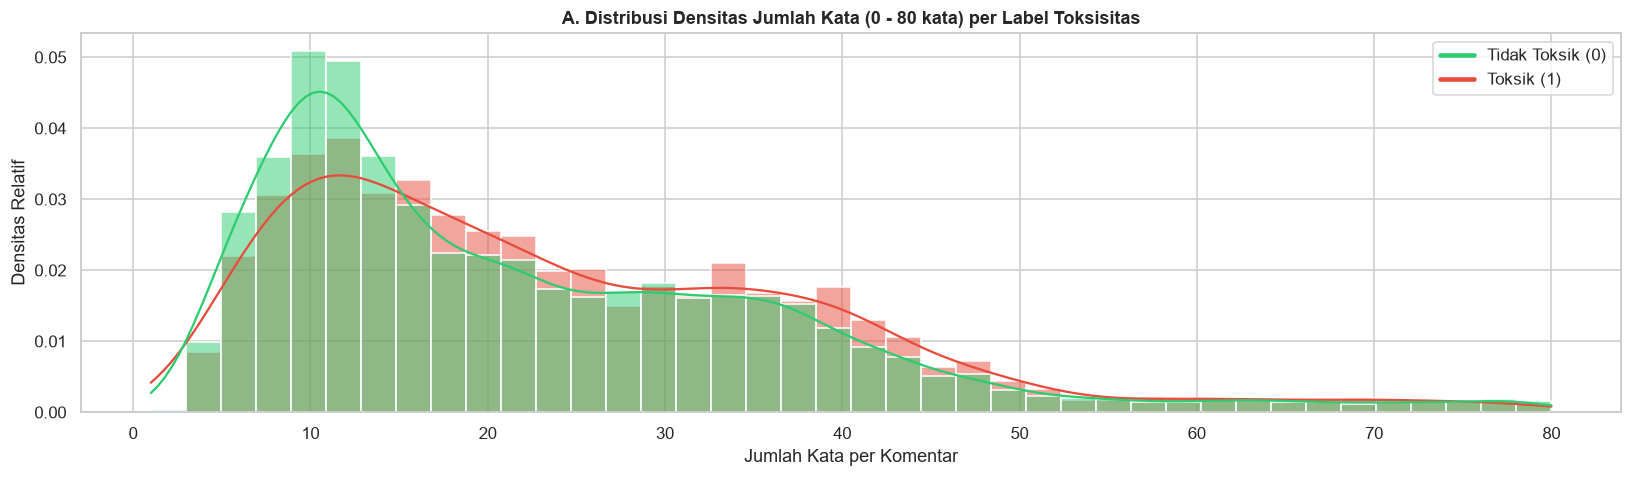

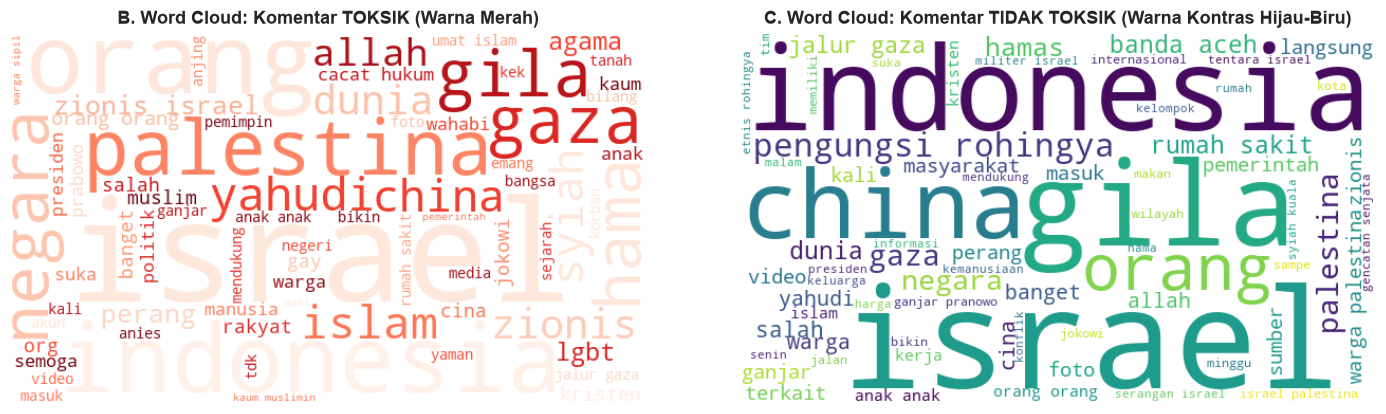

In [16]:
# 1. Pipeline Pembersihan Teks & Kamus Stopwords
indo_sw = set(stopwords.words('indonesian')).union({
    'yg', 'dgn', 'utk', 'ga', 'gak', 'bgt', 'tp', 'kalo', 'klo', 'nya', 'sy', 'nih', 
    'aja', 'sih', 'deh', 'dong', 'udah', 'ini', 'itu', 'di', 'dan', 'dari', 'ke', 'ya', 
    'ada', 'bisa', 'akan', 'tak', 'sama', 'buat', 'juga', 'jadi', 'pada', 'lah', 'kok',
    'si', 'lu', 'gw', 'gue', 'lo', 'gua', 'udah', 'tau', 'kan', 'dong', 'apa', 'lagi'
})

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)       # Hapus URL
    text = re.sub(r'@\w+', ' ', text)                   # Hapus Mention
    text = re.sub(r'#\w+', ' ', text)                   # Hapus Hashtag
    text = re.sub(r'\d+', ' ', text)                    # Hapus Angka
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)            # Hapus Karakter Khusus & Emoji
    text = re.sub(r'\s+', ' ', text).strip()             # Rapikan Spasi
    return text

def remove_sw(text):
    words = text.split()
    return ' '.join([w for w in words if w not in indo_sw and len(w) > 2])

# Terapkan pipeline
df['text_clean'] = df['text'].apply(clean_text)
df['tokens_clean'] = df['text_clean'].apply(remove_sw)

# 2. Perhitungan Log-Odds Ratio (Kata Paling Khas / Diskriminatif)
vec = CountVectorizer(min_df=5, max_features=1200)
X = vec.fit_transform(df['tokens_clean'])
vocab = np.array(vec.get_feature_names_out())
y = df['toxicity'].values

# Laplace smoothing (+1)
cnt_tox = np.asarray(X[y == 1].sum(axis=0)).flatten() + 1
cnt_nontox = np.asarray(X[y == 0].sum(axis=0)).flatten() + 1
log_odds = np.log((cnt_tox / cnt_tox.sum()) / (cnt_nontox / cnt_nontox.sum()))

# Top kata khas
idx_top_tox = np.argsort(log_odds)[-10:][::-1]
idx_top_nontox = np.argsort(log_odds)[:10]

df_discriminative = pd.DataFrame({
    'Kata Paling Khas TOKSIK': vocab[idx_top_tox],
    'Log-Odds (Toksik)': log_odds[idx_top_tox].round(2),
    'Kata Paling Khas TIDAK TOKSIK': vocab[idx_top_nontox],
    'Log-Odds (Tidak Toksik)': (-log_odds[idx_top_nontox]).round(2)
})
print("Top 10 Kata Paling Diskriminatif (Log-Odds Ratio):")
display(df_discriminative)

# 3. Visualisasi Densitas Panjang Kata (Gambar 1)
fig, ax = plt.subplots(figsize=(15, 4.5))
sns.histplot(data=df[df['word_count'] <= 80], x='word_count', hue='toxicity', bins=40,
             kde=True, stat='density', common_norm=False, palette={0: '#2ECC71', 1: '#E74C3C'}, ax=ax)
ax.set_title('A. Distribusi Densitas Jumlah Kata (0 - 80 kata) per Label Toksisitas', fontweight='bold', fontsize=12)
ax.set_xlabel('Jumlah Kata per Komentar')
ax.set_ylabel('Densitas Relatif')
handles = [plt.Line2D([0], [0], color='#2ECC71', lw=3), plt.Line2D([0], [0], color='#E74C3C', lw=3)]
ax.legend(handles, ['Tidak Toksik (0)', 'Toksik (1)'], loc='upper right')
plt.tight_layout()
plt.show()

# 4. Visualisasi Komparasi Word Cloud (Gambar 2: Layout Stabil, Kontras Tinggi)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Word Cloud Toksik (Merah)
tox_tokens = df[df['toxicity'] == 1]['tokens_clean'].dropna()
sample_tox = tox_tokens.sample(min(6000, len(tox_tokens)), random_state=42) if len(tox_tokens) > 0 else tox_tokens
wc_tox = WordCloud(width=600, height=350, background_color='white', colormap='Reds', max_words=70, random_state=42)\
    .generate(' '.join(sample_tox))
axes[0].imshow(wc_tox, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('B. Word Cloud: Komentar TOKSIK (Warna Merah)', fontweight='bold', fontsize=12)

# Word Cloud Tidak Toksik (Hijau-Biru Viridis Kontras Tinggi)
nontox_tokens = df[df['toxicity'] == 0]['tokens_clean'].dropna()
sample_nontox = nontox_tokens.sample(min(6000, len(nontox_tokens)), random_state=42) if len(nontox_tokens) > 0 else nontox_tokens
wc_nontox = WordCloud(width=600, height=350, background_color='white', colormap='viridis', max_words=70, random_state=42)\
    .generate(' '.join(sample_nontox))
axes[1].imshow(wc_nontox, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('C. Word Cloud: Komentar TIDAK TOKSIK (Warna Kontras Hijau-Biru)', fontweight='bold', fontsize=12)

plt.subplots_adjust(wspace=0.15)
plt.show()